In [ ]:
!pip install http://download.pytorch.org/whl/cu80/torch-0.3.0.post4-cp36-cp36m-linux_x86_64.whl
!pip3 install -q torch torchvision
!pip3 install -q opencv-python
!pip install Pillow==4.0.0

    14% |████▋                           | 85.3MB 73.4MB/s eta 0:00:07

    100% |████████████████████████████████| 592.3MB 8.8MB/s 
    100% |████████████████████████████████| 5.6MB 4.7MB/s 
torchvision 0.2.1 has requirement pillow>=4.1.1, but you'll have pillow 4.0.0 which is incompatible.
  Found existing installation: Pillow 5.2.0
    Uninstalling Pillow-5.2.0:
      Successfully uninstalled Pillow-5.2.0


In [ ]:
from googleapiclient.discovery import build
import io, os, sys
from googleapiclient.http import MediaIoBaseDownload
from google.colab import auth

def download_from_gdrive(download_filename, output_path):
    auth.authenticate_user()

    drive_service = build('drive', 'v3')
    key = "name = '%s'" % download_filename
    results = drive_service.files().list(
       q=key, fields="files(id)").execute()
    fileid = results.get('files', [])[0]['id']

    request = drive_service.files().get_media(fileId=fileid)
    fh = io.FileIO(output_path, 'wb')
    downloader = MediaIoBaseDownload(fh, request)

    done = False
    while done is False:
        status, done = downloader.next_chunk()
        sys.stdout.write("\rDownload %d%%." % int(status.progress() * 100))
        sys.stdout.flush()
    print("")

In [ ]:
download_from_gdrive("imagenet-loc.tar.gz", "/content/imagenet-loc.tar.gz")
!tar zxf imagenet-loc.tar.gz

Download 100%.


## Object Detection
- Classification :<br> the way to know 'What is it' and returns predicted labelname and score
- Object Detection:<br> the way to know 'Where is what' and returns label name, score, and bouding box

<img src="https://github.com/yusukeh0710/notebook/raw/master/material/object_detection.png" width=50%>

In [ ]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class ImagenetLocDataset(torch.utils.data.Dataset):
    def __init__(self, data_csv, image_dir, synset_txt, transform=None):
        self.transform = transform

        with open(synset_txt, 'r') as f:
            self.synset = []
            self.synset_words = []
            for idx, line in enumerate(f):
                items = line.strip('\n').split(' ')
                key, name = items[0], ' '.join(items[1:]).split(',')[0]
                self.synset.append(key)
                self.synset_words.append(name)

            self.synset = np.array(self.synset)

        # Prepare dataset.
        self.samples = []
        with open(data_csv, 'r') as f:
            f.readline()
            for line in f:
                line = line.strip('\n')
                filename, data = line.split(',')

                # Image
                path = image_dir + '/' + filename + '.JPEG'

                # Target
                items = data.split(' ')
                num_target = int(len(items) / 5)

                targets = []
                for i in range(num_target):
                    label_key = items[5*i]
                    label_idx = np.where(self.synset == label_key)[0][0]

                    bbox = items[5*i+1:5*i+5]
                    target = [int(string) for string in bbox]
                    target.append(label_idx)

                    targets.append(target)

                # Append image path and label information
                self.samples.append((path, targets))

            # Swap for explanation.
            self.samples[2], self.samples[0] = self.samples[0], self.samples[2]


    def __getitem__(self, index):
        path, targets = self.samples[index]

        sample = Image.open(path)
        if sample.mode != 'RGB':
            sample.mode == 'RGB'

        if self.transform:
            sample = self.transform(sample)

        return sample, np.array(targets)

    def __len__(self):
        return len(self.samples)

dataset = ImagenetLocDataset('/content/imagenet-loc/data.csv', '/content/imagenet-loc/images', '/content/imagenet-loc/synset.txt')
labeltable = dataset.synset_words

#### Dataset structure:


```
bouding_box = [x_min, y_min, x_max, y_max, label_idx]
dataset = [
    (image_data#A, [bouding_box#A1, bouding_box#A2, ...]),
    (image_data#B, [bouding_box#B1, ...]),
    ...
]

labeltable = [
    label_name#1, label_name#2, ...
]
```

In [ ]:
%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from PIL import Image
import torch
from torch import nn, optim
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys

def to_np(torch_image):
    return torch_image.numpy().transpose([1, 2, 0]).copy()

Dataset example


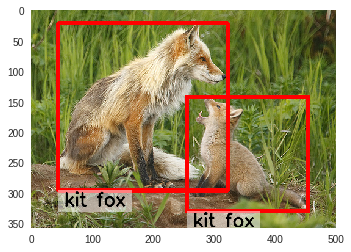

In [ ]:
print("Dataset example")

pil_image, targets = dataset[0]
image = np.asarray(pil_image)

tbox_w = 120
tbox_margin = 10
tbox_alpha = 0.5
text_offset_x = 10
text_offset_y = 25

for min_x, min_y, max_x, max_y, label_idx in targets:
    # Draw ROI.
    cv2.rectangle(image, (min_x, min_y), (max_x, max_y), (255, 0, 0), 5)

    # Draw text box with alpha transparentness.
    overlay = image.copy()
    cv2.rectangle(overlay, (min_x, max_y), (min_x + tbox_w, max_y + text_offset_y + tbox_margin), (255, 255, 255), -1)
    cv2.addWeighted(overlay, 1 - tbox_alpha, image, tbox_alpha, 0, image)

    # Draw label name in text box.
    labelname = labeltable[label_idx]
    cv2.putText(image, labelname, (min_x + text_offset_x, max_y + text_offset_y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)

plt.grid(False)
plt.imshow(image)

### R-CNN (Regions with CNN features)
refference: <br>
https://www.cv-foundation.org/openaccess/content_cvpr_2014/papers/Girshick_Rich_Feature_Hierarchies_2014_CVPR_paper.pdf

<img src="https://github.com/yusukeh0710/notebook/raw/master/material/object_detection_RCNN.png" width=60%>

Abstract:
1. Create candidate regions using region proposal
1. Crop each region and resize it to the size of input layer of classifier
1. Extract features
1. Classify the resion with above extracted features

In refference paper, 1. Create regions using selective search[1], 2. Extract features using AlexNet, 3. Classify it using SVM

By the way, in this time, I use VGG16 as feature extractor and classifier intead of AlexNet/SVM to make implementation simple.

[1] https://ivi.fnwi.uva.nl/isis/publications/2013/UijlingsIJCV2013/UijlingsIJCV2013.pdf

#### Selective Search

In [ ]:
!pip -q install selectivesearch

In [ ]:
from selectivesearch import selective_search

pil_image, targets = dataset[0]
image = np.asarray(pil_image)

# selective_search(image, scale=1.0, sigma=0.8, min_size=50)
#   image: ndarray, input image
#   scale: int, higher value means good large clusters in felzenszwalb segmentation
#   sigma: float, width of Gaussian kernel for felzenszwalb segmentation
#   min_size: int, minimum component size for felzenszwalb segmentation
_, regions = selective_search(image, scale=500, sigma=0.9, min_size=10)
for region in regions[:5]:
    print(region)

{'rect': (0, 0, 499, 356), 'size': 138015, 'labels': [0.0]}
{'rect': (29, 0, 1, 19), 'size': 20, 'labels': [1.0]}
{'rect': (186, 0, 8, 10), 'size': 73, 'labels': [2.0]}
{'rect': (484, 0, 5, 18), 'size': 110, 'labels': [3.0]}
{'rect': (490, 0, 1, 7), 'size': 14, 'labels': [4.0]}


In [ ]:
def visualize_regions(pil_image, regions, color=(255, 0, 0)):
    image = np.asarray(pil_image)
    for region in regions:
        x, y, w, h = region["rect"]
        cv2.rectangle(image, (x, y), (x+w, y+h), color, 2, cv2.LINE_AA)
    plt.grid(False)
    plt.imshow(image)
    plt.show()

def visualize_rect(pil_image, rects, color=(255, 0, 0)):
    regions = [
        {'rect': rect} for rect in rects
    ]
    visualize_regions(pil_image, regions, color)

In [ ]:
one_label_regions = []
two_labels_regions = []
three_labels_regions = []
threshold_size = 20
for region in regions:
    # Check rect size
    x, y, w, h = region["rect"]
    if (w <= threshold_size) or (h <= threshold_size):
        continue

    # Append region in accordance with num_labels
    num_labels = len(region["labels"])
    if num_labels == 1:
        one_label_regions.append(region)
    elif num_labels == 2:
        two_labels_regions.append(region)
    elif num_labels == 3:
        three_labels_regions.append(region)

one label regions


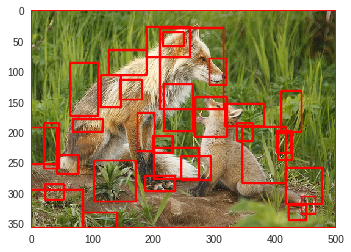

two labels regions


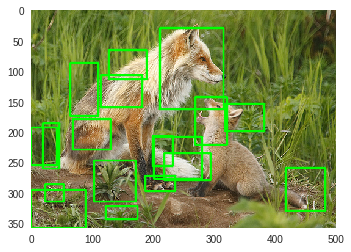

three labels regions


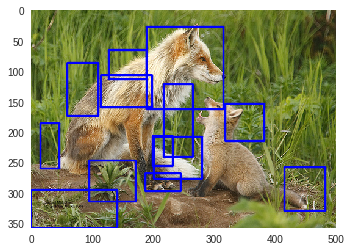

In [ ]:
print("one label regions")
visualize_regions(pil_image, one_label_regions, (255, 0, 0))

print("two labels regions")
visualize_regions(pil_image, two_labels_regions, (0, 255, 0))

print("three labels regions")
visualize_regions(pil_image, three_labels_regions, (0, 0, 255))

Default


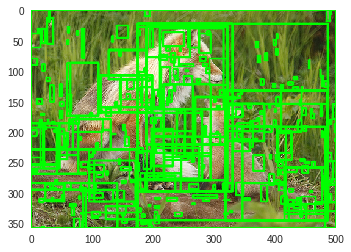

Higher scale


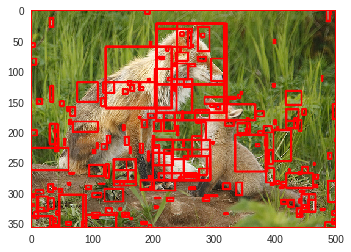

Lower scale


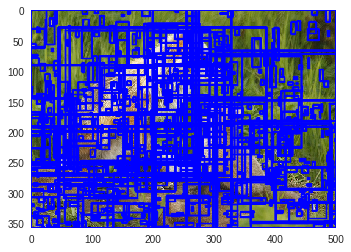

Higher sigma


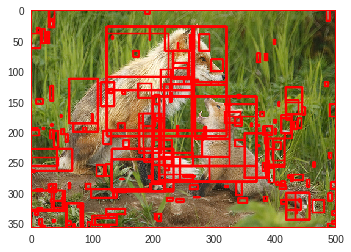

Lower sigma


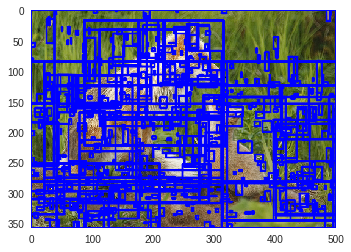

Higher min_size


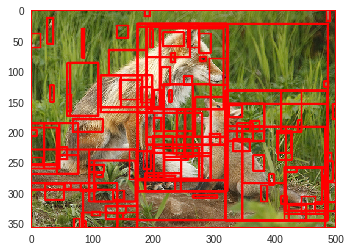

Lower min_size


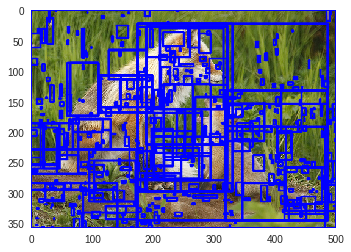

In [ ]:
print("Default")
_, regions = selective_search(image, scale=500, sigma=0.9, min_size=10)
visualize_regions(pil_image, regions, (0, 255, 0))

# Scale
print("Higher scale")
_, regions = selective_search(image, scale=1000, sigma=0.9, min_size=10)
visualize_regions(pil_image, regions, (255, 0, 0))

print("Lower scale")
_, regions = selective_search(image, scale=200, sigma=0.9, min_size=10)
visualize_regions(pil_image, regions, (0, 0, 255))

# Sigma
print("Higher sigma")
_, regions = selective_search(image, scale=500, sigma=1.5, min_size=10)
visualize_regions(pil_image, regions, (255, 0, 0))

print("Lower sigma")
_, regions = selective_search(image, scale=500, sigma=0.5, min_size=10)
visualize_regions(pil_image, regions, (0, 0, 255))

# min_size
print("Higher min_size")
_, regions = selective_search(image, scale=500, sigma=0.9, min_size=50)
visualize_regions(pil_image, regions, (255, 0, 0))

print("Lower min_size")
_, regions = selective_search(image, scale=500, sigma=0.9, min_size=5)
visualize_regions(pil_image, regions, (0, 0, 255))

Proposed Regions:


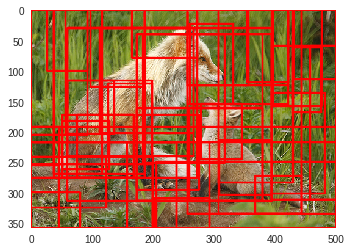

In [ ]:
# 1. Region Proposal
def propose_region(pil_image):
    image = np.asarray(pil_image)
    _, region_candidates = selective_search(image, scale=100, sigma=0.9, min_size=1500)

    regions = []
    for region in region_candidates:
        x, y, w, h = region['rect']

        if [x, y, w, h] in regions:
            continue

        if w == 0 or h == 0:
            continue

        regions.append([x, y, w, h])
    return regions

pil_image, targets = dataset[0]
region_rects = propose_region(pil_image)

plt.rcParams['figure.figsize'] = [6.0, 4.0]
print("Proposed Regions:")
visualize_rect(pil_image, region_rects)
plt.show()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /content/.torch/models/vgg16-397923af.pth
1.2%

100.0%


Classification results:


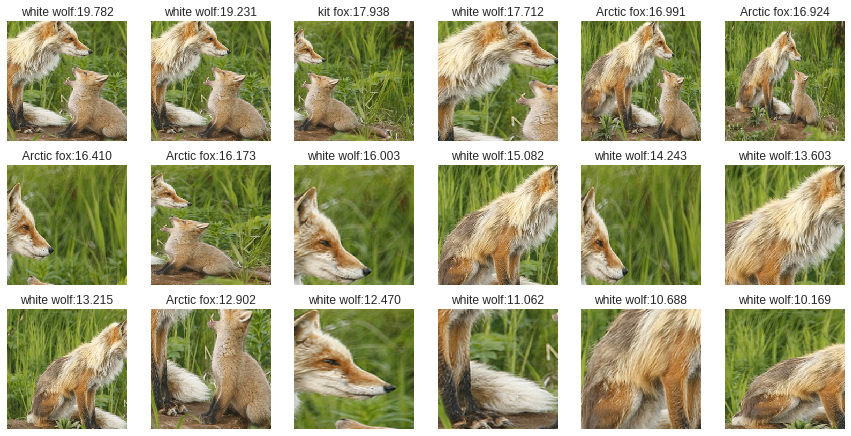

In [ ]:
# 2. Extract Features
# 3. Classify Regions
vgg16 = models.vgg16(pretrained=True)
vgg16.cuda()
vgg16.eval()
input_w = 224
input_h = 224

def crop_and_resize(pil_image, region, size_w, size_h):
    x, y, w, h = region
    transform = transforms.Compose([
        transforms.Resize(size=(size_h, size_w)),
        transforms.ToTensor()
    ])
    cropped_image = pil_image.crop([x, y, x+w, y+h])
    return transform(cropped_image).clamp(min=0, max=1.0)

def predict(image, model):
    data = image.unsqueeze(0)
    data = data.cuda()
    data = Variable(data)
    output = model(data)
    score, pred = torch.max(output.data, 1)
    return pred[0], score[0]

def visualize_result(preds, display_col):
    display_row = math.ceil(len(preds) / display_col)
    figsize_h = display_row * 2.5
    plt.rcParams['figure.figsize'] = [15.0, figsize_h]

    for cnt, (score, labelname, image, rect) in enumerate(preds):
        plt.subplot(display_row, display_col, cnt+1)
        plt.imshow(image)
        plt.title("%s:%.3f" % (labelname, score))
        plt.grid(False)
        plt.tick_params(labelleft = "off", labelbottom = "off")
    plt.show()

pred_list = []  # [(score, labelname, np_image)]
for rect in region_rects:
    resized_image = crop_and_resize(pil_image, rect, input_w, input_h)
    pred_idx, score = predict(resized_image, vgg16)
    labelname = labeltable[pred_idx]
    pred_list.append((score, labelname, to_np(resized_image), rect))

print("Classification results:")
sorted_list = sorted(pred_list, key=lambda x:x[0], reverse=True)
visualize_result(sorted_list[:18], 6)

### Performance indicators for prediction
- Basic indicators<br>
  -  $$Accuracy = \frac{TP + TN}{TP + FP + FN + TN}$$

  -  $$Recall = \frac{TP}{TP+FN}$$
  
  -  $$Precision = \frac{TP}{TP+FP}$$
  
  -  $$F value = \frac{2Recall \cdot Precision}{Recall + Precision}$$

- IoU (Intersectioin of Union):
  - Evaluation criterion for the location of extracted region<br>
    $$IoU = \frac{Area　of　Overlap}{Area　of　Union}$$
  - IoU is used as threshold, e.g. <br>
    for threshold = 0.5, if IoU of the location is 0.7,  the region is positive

- ROC(Receiver Operating Characteristic) / AUC(Area Under the Curve)
  - ROC curve: The curve which x-axis is False Positive rate and y-axis is True Positive rate
    - True Positive rate: TP/ (TP + FN),  the rate of true positive for actual positive (=Recall)
    - False Positive rate: FP / (FP + TN), the rate of false positive for actual negative
  - AUC: The area of uncer ROC curve
    - 0.0 < ROC-AUC < 1.0, and higher ROC-AUC means good predictor
    
- Average Precision (AP)
  - Exact average precision: AUC of Precision-Recall curve
  - Approximated average precison:
    1. Sort items with their rank
    2. Calculate precision for each threshold used when positive item appears until all positive items are found or all items are checked
    3. Take an average of 2. precisions

Example with following image classification results:

| label  | O | X | O | X | O | O | O | X | O | X | O |
|------|------|
| score | 0.7 | 0.5 | 0.3 | 0.6 | 0.9 | 0.8 | 0.3 | 0.2 | 0.5 | 0.1 | 0.9 |
* O: Actual is Positive,  X: Actual is Negative  
* Predictor judge, if score is over the threshold, then it is positive, else negtive.  

#### ROC / AUC

Text(0.5,1,'ROC Curve (AUC = 0.804)')

Text(0.5,0,'False Posiive rate')

Text(0,0.5,'True Positive rate')

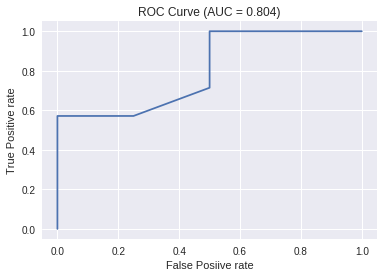

In [ ]:
results = [(True, 0.7), (False, 0.5), (True, 0.3), (False, 0.6), (True, 0.9), (True, 0.8), (True, 0.3), (False, 0.2), (True, 0.5), (False, 0.1), (True, 0.9)]

def result_generator(results, threshold):
    tp, fn, fp, tn = 0, 0, 0, 0

    for actual, score in results:
        pred = score > threshold
        if actual:
            if pred:
                tp += 1
            else:
                fn += 1
        else:
            if pred:
                fp += 1
            else:
                tn += 1
    return tp, fn, fp, tn

tpr_list = []
fpr_list = []
for th in np.arange(1.0, 0.0, -0.01):
    tp, fn, fp, tn = result_generator(results, th-0.01)
    tpr_list.append(tp / (tp + fn))
    fpr_list.append(fp / (fp + tn))

# Calculate AUC
auc = 0.0
prev_tpr = tpr_list[0]
prev_fpr = fpr_list[0]
for tpr, fpr in zip(tpr_list, fpr_list):
    if fpr != prev_fpr:
        auc += (prev_tpr + tpr) * (fpr - prev_fpr) / 2

    prev_tpr = tpr
    prev_fpr = fpr

plt.title('ROC Curve (AUC = %.3f)' % auc)
plt.xlabel('False Posiive rate')
plt.ylabel('True Positive rate')
plt.plot(fpr_list, tpr_list)

#### AP
Approximate solution:
1. Given label/score and information on the number of positive items
1. Sort items with their rank ( = score in this time)
1. When positive label appears, calculate the precision, and push into list
1. Take an average of 2. list

Exact solution:
1. Draw Precision-Recall Curve
2. Calculate AUC of PR curve

In [ ]:
print("Given label/score list %s" % results)
sorted_results = sorted(results, key=lambda tup: tup[1], reverse=True)
print("Sorted list: ", sorted_results)

total_positive = 0
for actual, _ in sorted_results:
    if actual:
        total_positive += 1

df = pd.DataFrame(index=[], columns=['label', 'actual', 'precision', 'recall'])
cnt_positive = 0
for idx, (actual, _) in enumerate(sorted_results):
    if actual:
        cnt_positive += 1

    precision = cnt_positive / (idx + 1)
    recall = cnt_positive / total_positive
    series = pd.Series([actual, "o" if actual else "x", precision, recall], index=df.columns)
    df = df.append(series, ignore_index=True)

df[["actual","precision"]].T

Given label/score list [(True, 0.7), (False, 0.5), (True, 0.3), (False, 0.6), (True, 0.9), (True, 0.8), (True, 0.3), (False, 0.2), (True, 0.5), (False, 0.1), (True, 0.9)]
Sorted list:  [(True, 0.9), (True, 0.9), (True, 0.8), (True, 0.7), (False, 0.6), (False, 0.5), (True, 0.5), (True, 0.3), (True, 0.3), (False, 0.2), (False, 0.1)]


,0,1,2,3,4,5,6,7,8,9,10
actual,o,o,o,o,x,x,o,o,o,x,x
precision,1,1,1,1,0.8,0.666667,0.714286,0.75,0.777778,0.7,0.636364


In [ ]:
df[df.label][["actual", "precision"]].T

print("\nAverage Precision: %.3f" % df.query("label == True")["precision"].mean())

,0,1,2,3,6,7,8
actual,o,o,o,o,o,o,o
precision,1,1,1,1,0.714286,0.75,0.777778



Average Precision: 0.892


,0,1,2,3,4,5,6,7,8,9,10
actual,o,o,o,o,x,x,o,o,o,x,x
precision,1,1,1,1,0.8,0.666667,0.714286,0.75,0.777778,0.7,0.636364
recall,0.142857,0.285714,0.428571,0.571429,0.571429,0.571429,0.714286,0.857143,1,1,1


Text(0.5,1,'Precision-Recall Curve')

Text(0.5,0,'Recall')

Text(0,0.5,'Precision')

(0, 1.0)

(0, 1.0)

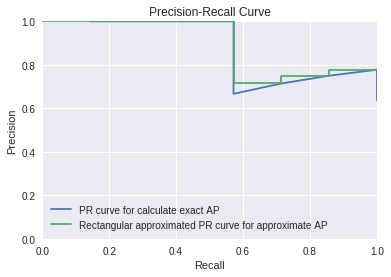

Exact average precision: 0.883787
Approximate average precision: 0.891723


In [ ]:
df[["actual", "precision", "recall"]].T

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim(0, 1.0)
plt.ylim(0, 1.0)

plt.plot(df["recall"], df["precision"], label="PR curve for calculate exact AP")

prev_p = 1.0
prev_r = 0.0
auc = 0
app_auc = 0
app_pr_curve_plots = []

for r, p in zip(df["recall"], df["precision"]):
    if r != prev_r:
        auc += (prev_p + p) * (r - prev_r) / 2
        app_auc += p * (r - prev_r)
        app_pr_curve_plots.append((p, prev_r))
        app_pr_curve_plots.append((p, r))

    prev_p = p
    prev_r = r

auc += (prev_p) * (1.0 - prev_r)

x = [r for p, r in app_pr_curve_plots]
y = [p for p, r in app_pr_curve_plots]
plt.plot(x, y, label="Rectangular approximated PR curve for approximate AP")

plt.legend()
plt.show()

print("Exact average precision: %lf" % auc)
print("Approximate average precision: %lf" % app_auc)

### Performance indicator for object detection
- Criterion related to location of bounding box
  - The way using IoU as threshold is major
  - $$ IOU = \frac{Area　of　Overlap}{Area　of　Union} $$

- Performance indicator
  - mAP (mean Average Precision) is major
    1. classify for each extracted region
    2. sort the score of classification such as likelyhood for each category
    3. evaluate each results
      - Calculate IoU between label's bouding box and prediction's bounding box
      - If the IoU is over threshold, then check whether pred's classification result is match label's category
      - If result and category are same, the predicion is marked as success, else as failure
    4. Calculate AP for each category 3.'s calculation and take an average of their AP for each category
